In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("cleaned_without.csv")

X = df.drop(columns=["listPrice"])
y = df["listPrice"]

print("Data loaded:", df.shape)

Data loaded: (7733, 14)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(len(X_train), len(X_val), len(X_test))

5413 1160 1160


In [ ]:
# ── Model 1: Default ──────────────────────────────────────
rf_default = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)

val_pred_default = rf_default.predict(X_val)
test_pred_default = rf_default.predict(X_test)

print("── Default ──")
print("Val R²:  ", round(r2_score(y_val, val_pred_default), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val, val_pred_default)), 4))
print("Val MAE: ", round(mean_absolute_error(y_val, val_pred_default), 4))
print("Test R²:  ", round(r2_score(y_test, test_pred_default), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred_default)), 4))
print("Test MAE: ", round(mean_absolute_error(y_test, test_pred_default), 4))

# ── Model 2: Tuned ────────────────────────────────────────
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

val_pred_tuned = rf_tuned.predict(X_val)
test_pred_tuned = rf_tuned.predict(X_test)

print("\n── Tuned ──")
print("Val R²:  ", round(r2_score(y_val, val_pred_tuned), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val, val_pred_tuned)), 4))
print("Val MAE: ", round(mean_absolute_error(y_val, val_pred_tuned), 4))
print("Test R²:  ", round(r2_score(y_test, test_pred_tuned), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred_tuned)), 4))
print("Test MAE: ", round(mean_absolute_error(y_test, test_pred_tuned), 4))

# After seeing results, save whichever is better
import joblib
joblib.dump(rf_default, "rf_without_text_default.pkl")
joblib.dump(rf_tuned, "rf_without_text_tuned.pkl")


── Default ──
Val R²:   0.6219
Val RMSE: 0.3772
Val MAE:  0.2608
Test R²:   0.5388
Test RMSE: 0.4393
Test MAE:  0.2868

── Tuned ──
Val R²:   0.6326
Val RMSE: 0.3718
Val MAE:  0.2546
Test R²:   0.5574
Test RMSE: 0.4304
Test MAE:  0.2822

Both models saved!


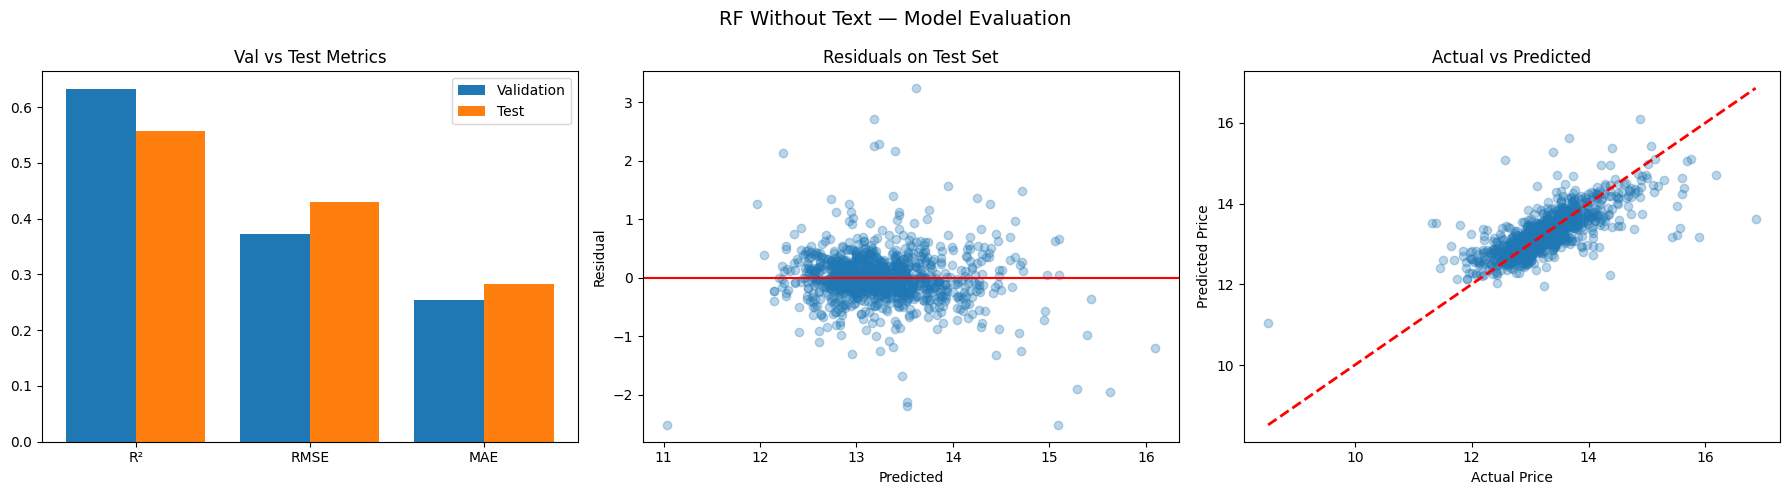

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # ← add this
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RF Without Text — Model Evaluation', fontsize=14)

# Plot 1 — Val vs Test metrics
metrics = ['R²', 'RMSE', 'MAE']
val_scores = [r2_score(y_val, val_pred_tuned),
              np.sqrt(mean_squared_error(y_val, val_pred_tuned)),
              mean_absolute_error(y_val, val_pred_tuned)]
test_scores = [r2_score(y_test, test_pred_tuned),
               np.sqrt(mean_squared_error(y_test, test_pred_tuned)),
               mean_absolute_error(y_test, test_pred_tuned)]

x = np.arange(len(metrics))
axes[0].bar(x - 0.2, val_scores, 0.4, label='Validation')
axes[0].bar(x + 0.2, test_scores, 0.4, label='Test')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Val vs Test Metrics')
axes[0].legend()

# Plot 2 — Residuals
residuals = y_test - test_pred_tuned
axes[1].scatter(test_pred_tuned, residuals, alpha=0.3)
axes[1].axhline(0, color='red')
axes[1].set_title('Residuals on Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

# Plot 3 — Actual vs Predicted
axes[2].scatter(y_test, test_pred_tuned, alpha=0.3)
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')

plt.tight_layout()
plt.savefig("rf_without_text_evaluation.png")
plt.show()